In [1]:
# run this to see all the outputs below each cell, not only the last instruction
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


# convert .xml to YOLO .txt label

In [2]:
import os
import xml.etree.ElementTree as ET

# Paths
XML_DIR = "/media/nima/7CEEFEC0EEFE71AE/space/FLIR/label/"          # folder containing XML files
TXT_DIR = "/media/nima/7CEEFEC0EEFE71AE/space/FLIR/label/"      # output folder for YOLO txt files

os.makedirs(TXT_DIR, exist_ok=True)

# Class mapping (EDIT THIS to match your dataset)
CLASS_MAPPING = {
    "person": 0,
    "car": 1,
    "bicycle": 2,
    # add more classes here
}

IMG_WIDTH = 640
IMG_HEIGHT = 512


def convert_xml_to_yolo(xml_path, txt_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    yolo_lines = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in CLASS_MAPPING:
            continue  # skip unknown classes

        class_id = CLASS_MAPPING[class_name]

        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        # Convert to YOLO format (normalized)
        x_center = ((xmin + xmax) / 2) / IMG_WIDTH
        y_center = ((ymin + ymax) / 2) / IMG_HEIGHT
        width = (xmax - xmin) / IMG_WIDTH
        height = (ymax - ymin) / IMG_HEIGHT

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        )

    with open(txt_path, "w") as f:
        f.write("\n".join(yolo_lines))


# Iterate over all XML files
for xml_file in os.listdir(XML_DIR):
    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(XML_DIR, xml_file)
    txt_file = xml_file.replace(".xml", ".txt")
    txt_path = os.path.join(TXT_DIR, txt_file)

    convert_xml_to_yolo(xml_path, txt_path)

print("✅ XML → YOLO TXT conversion completed.")


✅ XML → YOLO TXT conversion completed.


# plot an image with txt label

array([[[164, 174, 173],
        [155, 165, 164],
        [147, 156, 153],
        ...,
        [212, 235, 243],
        [216, 238, 251],
        [213, 235, 248]],

       [[178, 188, 187],
        [156, 166, 165],
        [144, 153, 150],
        ...,
        [214, 237, 245],
        [214, 236, 247],
        [212, 234, 247]],

       [[194, 203, 202],
        [178, 187, 186],
        [147, 156, 153],
        ...,
        [216, 239, 247],
        [214, 236, 247],
        [213, 235, 248]],

       ...,

       [[153, 153, 151],
        [149, 149, 147],
        [146, 146, 144],
        ...,
        [144, 145, 140],
        [145, 146, 141],
        [152, 153, 148]],

       [[157, 157, 155],
        [153, 153, 151],
        [148, 148, 146],
        ...,
        [148, 149, 144],
        [148, 149, 144],
        [146, 147, 142]],

       [[157, 157, 155],
        [156, 156, 154],
        [154, 154, 152],
        ...,
        [144, 145, 140],
        [147, 148, 143],
        [141, 142, 137]]

array([[[164, 174, 173],
        [155, 165, 164],
        [147, 156, 153],
        ...,
        [212, 235, 243],
        [216, 238, 251],
        [213, 235, 248]],

       [[178, 188, 187],
        [156, 166, 165],
        [144, 153, 150],
        ...,
        [214, 237, 245],
        [214, 236, 247],
        [212, 234, 247]],

       [[194, 203, 202],
        [178, 187, 186],
        [147, 156, 153],
        ...,
        [216, 239, 247],
        [214, 236, 247],
        [213, 235, 248]],

       ...,

       [[153, 153, 151],
        [149, 149, 147],
        [146, 146, 144],
        ...,
        [144, 145, 140],
        [145, 146, 141],
        [152, 153, 148]],

       [[157, 157, 155],
        [153, 153, 151],
        [148, 148, 146],
        ...,
        [148, 149, 144],
        [148, 149, 144],
        [146, 147, 142]],

       [[157, 157, 155],
        [156, 156, 154],
        [154, 154, 152],
        ...,
        [144, 145, 140],
        [147, 148, 143],
        [141, 142, 137]]

array([[[164, 174, 173],
        [155, 165, 164],
        [147, 156, 153],
        ...,
        [212, 235, 243],
        [216, 238, 251],
        [213, 235, 248]],

       [[178, 188, 187],
        [156, 166, 165],
        [144, 153, 150],
        ...,
        [214, 237, 245],
        [214, 236, 247],
        [212, 234, 247]],

       [[194, 203, 202],
        [178, 187, 186],
        [147, 156, 153],
        ...,
        [216, 239, 247],
        [214, 236, 247],
        [213, 235, 248]],

       ...,

       [[153, 153, 151],
        [149, 149, 147],
        [146, 146, 144],
        ...,
        [144, 145, 140],
        [145, 146, 141],
        [152, 153, 148]],

       [[157, 157, 155],
        [153, 153, 151],
        [148, 148, 146],
        ...,
        [148, 149, 144],
        [148, 149, 144],
        [146, 147, 142]],

       [[157, 157, 155],
        [156, 156, 154],
        [154, 154, 152],
        ...,
        [144, 145, 140],
        [147, 148, 143],
        [141, 142, 137]]

array([[[164, 174, 173],
        [155, 165, 164],
        [147, 156, 153],
        ...,
        [212, 235, 243],
        [216, 238, 251],
        [213, 235, 248]],

       [[178, 188, 187],
        [156, 166, 165],
        [144, 153, 150],
        ...,
        [214, 237, 245],
        [214, 236, 247],
        [212, 234, 247]],

       [[194, 203, 202],
        [178, 187, 186],
        [147, 156, 153],
        ...,
        [216, 239, 247],
        [214, 236, 247],
        [213, 235, 248]],

       ...,

       [[153, 153, 151],
        [149, 149, 147],
        [146, 146, 144],
        ...,
        [144, 145, 140],
        [145, 146, 141],
        [152, 153, 148]],

       [[157, 157, 155],
        [153, 153, 151],
        [148, 148, 146],
        ...,
        [148, 149, 144],
        [148, 149, 144],
        [146, 147, 142]],

       [[157, 157, 155],
        [156, 156, 154],
        [154, 154, 152],
        ...,
        [144, 145, 140],
        [147, 148, 143],
        [141, 142, 137]]

array([[[164, 174, 173],
        [155, 165, 164],
        [147, 156, 153],
        ...,
        [212, 235, 243],
        [216, 238, 251],
        [213, 235, 248]],

       [[178, 188, 187],
        [156, 166, 165],
        [144, 153, 150],
        ...,
        [214, 237, 245],
        [214, 236, 247],
        [212, 234, 247]],

       [[194, 203, 202],
        [178, 187, 186],
        [147, 156, 153],
        ...,
        [216, 239, 247],
        [214, 236, 247],
        [213, 235, 248]],

       ...,

       [[153, 153, 151],
        [149, 149, 147],
        [146, 146, 144],
        ...,
        [144, 145, 140],
        [145, 146, 141],
        [152, 153, 148]],

       [[157, 157, 155],
        [153, 153, 151],
        [148, 148, 146],
        ...,
        [148, 149, 144],
        [148, 149, 144],
        [146, 147, 142]],

       [[157, 157, 155],
        [156, 156, 154],
        [154, 154, 152],
        ...,
        [144, 145, 140],
        [147, 148, 143],
        [141, 142, 137]]

...

array([[[164, 174, 173],
        [155, 165, 164],
        [147, 156, 153],
        ...,
        [212, 235, 243],
        [216, 238, 251],
        [213, 235, 248]],

       [[178, 188, 187],
        [156, 166, 165],
        [144, 153, 150],
        ...,
        [214, 237, 245],
        [214, 236, 247],
        [212, 234, 247]],

       [[194, 203, 202],
        [178, 187, 186],
        [147, 156, 153],
        ...,
        [216, 239, 247],
        [214, 236, 247],
        [213, 235, 248]],

       ...,

       [[153, 153, 151],
        [149, 149, 147],
        [146, 146, 144],
        ...,
        [144, 145, 140],
        [145, 146, 141],
        [152, 153, 148]],

       [[157, 157, 155],
        [153, 153, 151],
        [148, 148, 146],
        ...,
        [148, 149, 144],
        [148, 149, 144],
        [146, 147, 142]],

       [[157, 157, 155],
        [156, 156, 154],
        [154, 154, 152],
        ...,
        [144, 145, 140],
        [147, 148, 143],
        [141, 142, 137]]

array([[[164, 174, 173],
        [155, 165, 164],
        [147, 156, 153],
        ...,
        [212, 235, 243],
        [216, 238, 251],
        [213, 235, 248]],

       [[178, 188, 187],
        [156, 166, 165],
        [144, 153, 150],
        ...,
        [214, 237, 245],
        [214, 236, 247],
        [212, 234, 247]],

       [[194, 203, 202],
        [178, 187, 186],
        [147, 156, 153],
        ...,
        [216, 239, 247],
        [214, 236, 247],
        [213, 235, 248]],

       ...,

       [[153, 153, 151],
        [149, 149, 147],
        [146, 146, 144],
        ...,
        [144, 145, 140],
        [145, 146, 141],
        [152, 153, 148]],

       [[157, 157, 155],
        [153, 153, 151],
        [148, 148, 146],
        ...,
        [148, 149, 144],
        [148, 149, 144],
        [146, 147, 142]],

       [[157, 157, 155],
        [156, 156, 154],
        [154, 154, 152],
        ...,
        [144, 145, 140],
        [147, 148, 143],
        [141, 142, 137]]

<Figure size 800x600 with 0 Axes>

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

Text(0.5, 1.0, 'YOLO Annotation Validation')

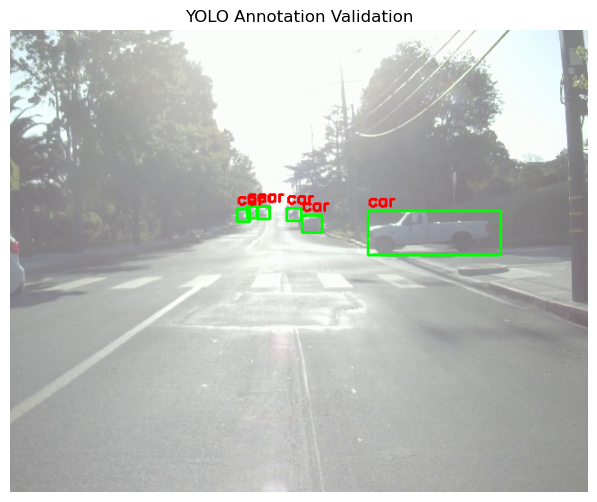

In [3]:
import cv2
import matplotlib.pyplot as plt

# Paths
IMAGE_PATH = "/media/nima/7CEEFEC0EEFE71AE/space/FLIR/img/FLIR_00002_RGB.jpg"       # change to a real image
LABEL_PATH = "/media/nima/7CEEFEC0EEFE71AE/space/FLIR/label/FLIR_00002_PreviewData.txt"    # corresponding txt file

# Class mapping (EDIT THIS to match your dataset)
CLASS_MAPPING = {
    "person": 0,
    "car": 1,
    "bicycle": 2,
    # add more classes here
}

# Reverse class mapping for visualization
ID_TO_CLASS = {v: k for k, v in CLASS_MAPPING.items()}

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Read YOLO labels
with open(LABEL_PATH, "r") as f:
    lines = f.readlines()

for line in lines:
    class_id, x_c, y_c, bw, bh = map(float, line.split())

    # Convert back to pixel coordinates
    x_c *= w
    y_c *= h
    bw *= w
    bh *= h

    xmin = int(x_c - bw / 2)
    ymin = int(y_c - bh / 2)
    xmax = int(x_c + bw / 2)
    ymax = int(y_c + bh / 2)

    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    label = ID_TO_CLASS[int(class_id)]
    cv2.putText(
        img, label, (xmin, ymin - 5),
        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2
    )

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO Annotation Validation")
plt.show()
